# EDA — OASIS-3 Raw Metadata
### Raw dataset analysis: missing values, data quality & filtering justification


---
This notebook analyses the **raw** OASIS-3 clinical metadata (`OASIS3_metadata.csv`).  
The goal is to characterise the dataset structure, quantify missing data, and justify
why most columns and sessions are removed before building the final cohort.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white',
                     'axes.spines.top':False,'axes.spines.right':False,
                     'axes.grid':True,'grid.alpha':0.3,'font.size':11})
DPI = 150


## 2. Dataset overview

In [2]:
raw = pd.read_csv('OASIS3_metadata.csv')

print(f'Shape          : {raw.shape[0]:,} rows  ×  {raw.shape[1]} columns')
print(f'Unique subjects: {raw["OASISID"].nunique():,}')
print(f'Total sessions : {len(raw):,}  (mean {len(raw)/raw["OASISID"].nunique():.1f} sessions/subject)')
print(f'Age range      : {raw["age at visit"].min():.1f} – {raw["age at visit"].max():.1f} years')
raw[['OASISID','OASIS_session_label','days_to_visit','age at visit',
     'NORMCOG','DEMENTED','MCIAMEM']].head(8)


Shape          : 8,499 rows  ×  149 columns
Unique subjects: 1,340
Total sessions : 8,499  (mean 6.3 sessions/subject)
Age range      : 42.5 – 100.5 years


,OASISID,OASIS_session_label,days_to_visit,age at visit,NORMCOG,DEMENTED,MCIAMEM
0,OAS30001,OAS30001_UDSd1_d0000,0,65.19,1.0,NaN,NaN
1,OAS30001,OAS30001_UDSd1_d0339,339,66.12,1.0,NaN,NaN
2,OAS30001,OAS30001_UDSd1_d0722,722,67.17,1.0,NaN,NaN
3,OAS30001,OAS30001_UDSd1_d1106,1106,68.22,1.0,NaN,NaN
4,OAS30001,OAS30001_UDSd1_d1456,1456,69.18,1.0,NaN,NaN
5,OAS30001,OAS30001_UDSd1_d1894,1894,70.38,1.0,NaN,NaN
6,OAS30001,OAS30001_UDSd1_d2181,2181,71.17,1.0,NaN,NaN
7,OAS30001,OAS30001_UDSd1_d2699,2699,72.59,1.0,NaN,NaN


## 3. Missing values — global overview

The raw metadata contains **149 clinical variables**.  
The vast majority are diagnosis-specific flags (e.g. DLB, FTD, PSP, vascular subtypes)
that are only filled when the condition is confirmed. 
This creates a structurally sparse matrix where most columns carry almost no information
for the CN/AD classification task of this project.


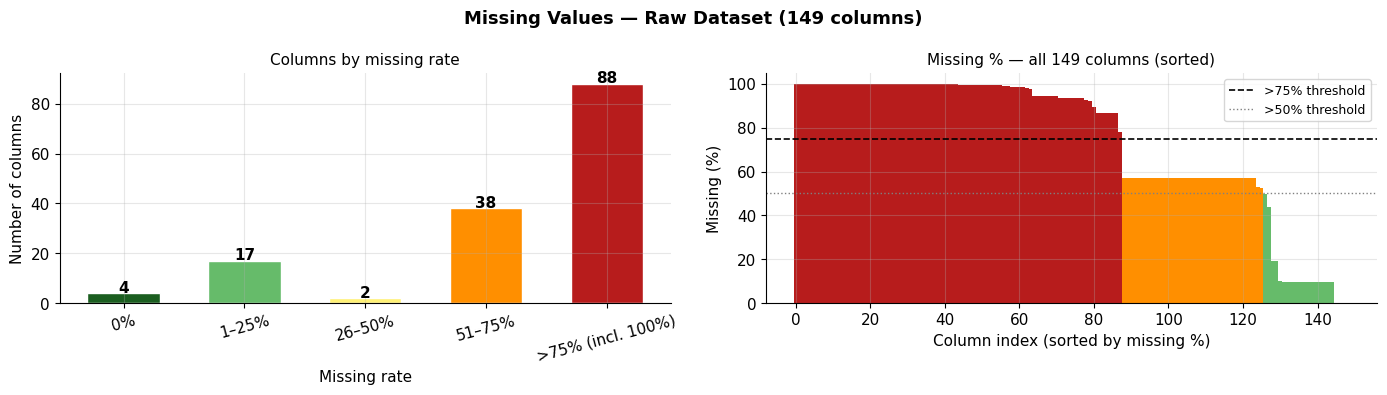

Columns with   0% missing : 4
Columns with 100% missing : 6  ← completely empty
Columns with  >75% missing: 88  ← unusable
Columns with  >50% missing: 126
Columns with  <50% missing: 23  ← potentially usable


In [3]:
null_pct = (raw.isnull().mean() * 100).sort_values(ascending=False)

# Categorise missingness
bins   = [-1, 0, 25, 50, 75, 100]
labels = ['0%', '1–25%', '26–50%', '51–75%', '>75% (incl. 100%)']
cat    = pd.cut(null_pct, bins=bins, labels=labels)
counts = cat.value_counts().reindex(labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Missing Values — Raw Dataset (149 columns)', fontsize=13, fontweight='bold')

# Bar: how many columns per missing category
ax = axes[0]
colors = ['#1B5E20','#66BB6A','#FFF176','#FF8F00','#B71C1C']
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.6)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            str(int(v)), ha='center', fontsize=11, fontweight='bold')
ax.set_title('Columns by missing rate', fontsize=11)
ax.set_xlabel('Missing rate'); ax.set_ylabel('Number of columns')
ax.tick_params(axis='x', rotation=15)

# Sorted bar: % missing for all 149 columns
ax = axes[1]
ax.bar(range(len(null_pct)), null_pct.values,
       color=['#B71C1C' if v > 75 else '#FF8F00' if v > 50
              else '#66BB6A' if v > 0 else '#1B5E20'
              for v in null_pct.values],
       width=1.0, edgecolor='none')
ax.axhline(75, color='black', lw=1.2, ls='--', label='>75% threshold')
ax.axhline(50, color='grey',  lw=1.0, ls=':', label='>50% threshold')
ax.set_title('Missing % — all 149 columns (sorted)', fontsize=11)
ax.set_xlabel('Column index (sorted by missing %)'); ax.set_ylabel('Missing (%)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_raw_missing_overview.png', dpi=DPI, bbox_inches='tight')
plt.show()

print(f'Columns with   0% missing : {(null_pct == 0).sum()}')
print(f'Columns with 100% missing : {(null_pct == 100).sum()}  ← completely empty')
print(f'Columns with  >75% missing: {(null_pct > 75).sum()}  ← unusable')
print(f'Columns with  >50% missing: {(null_pct > 50).sum()}')
print(f'Columns with  <50% missing: {(null_pct < 50).sum()}  ← potentially usable')


### 3.1 Missing pattern heatmap

Visualising the missing pattern on a random sample of sessions reveals the **block structure**:
identifiers and age are always present, most clinical flags are almost always absent.


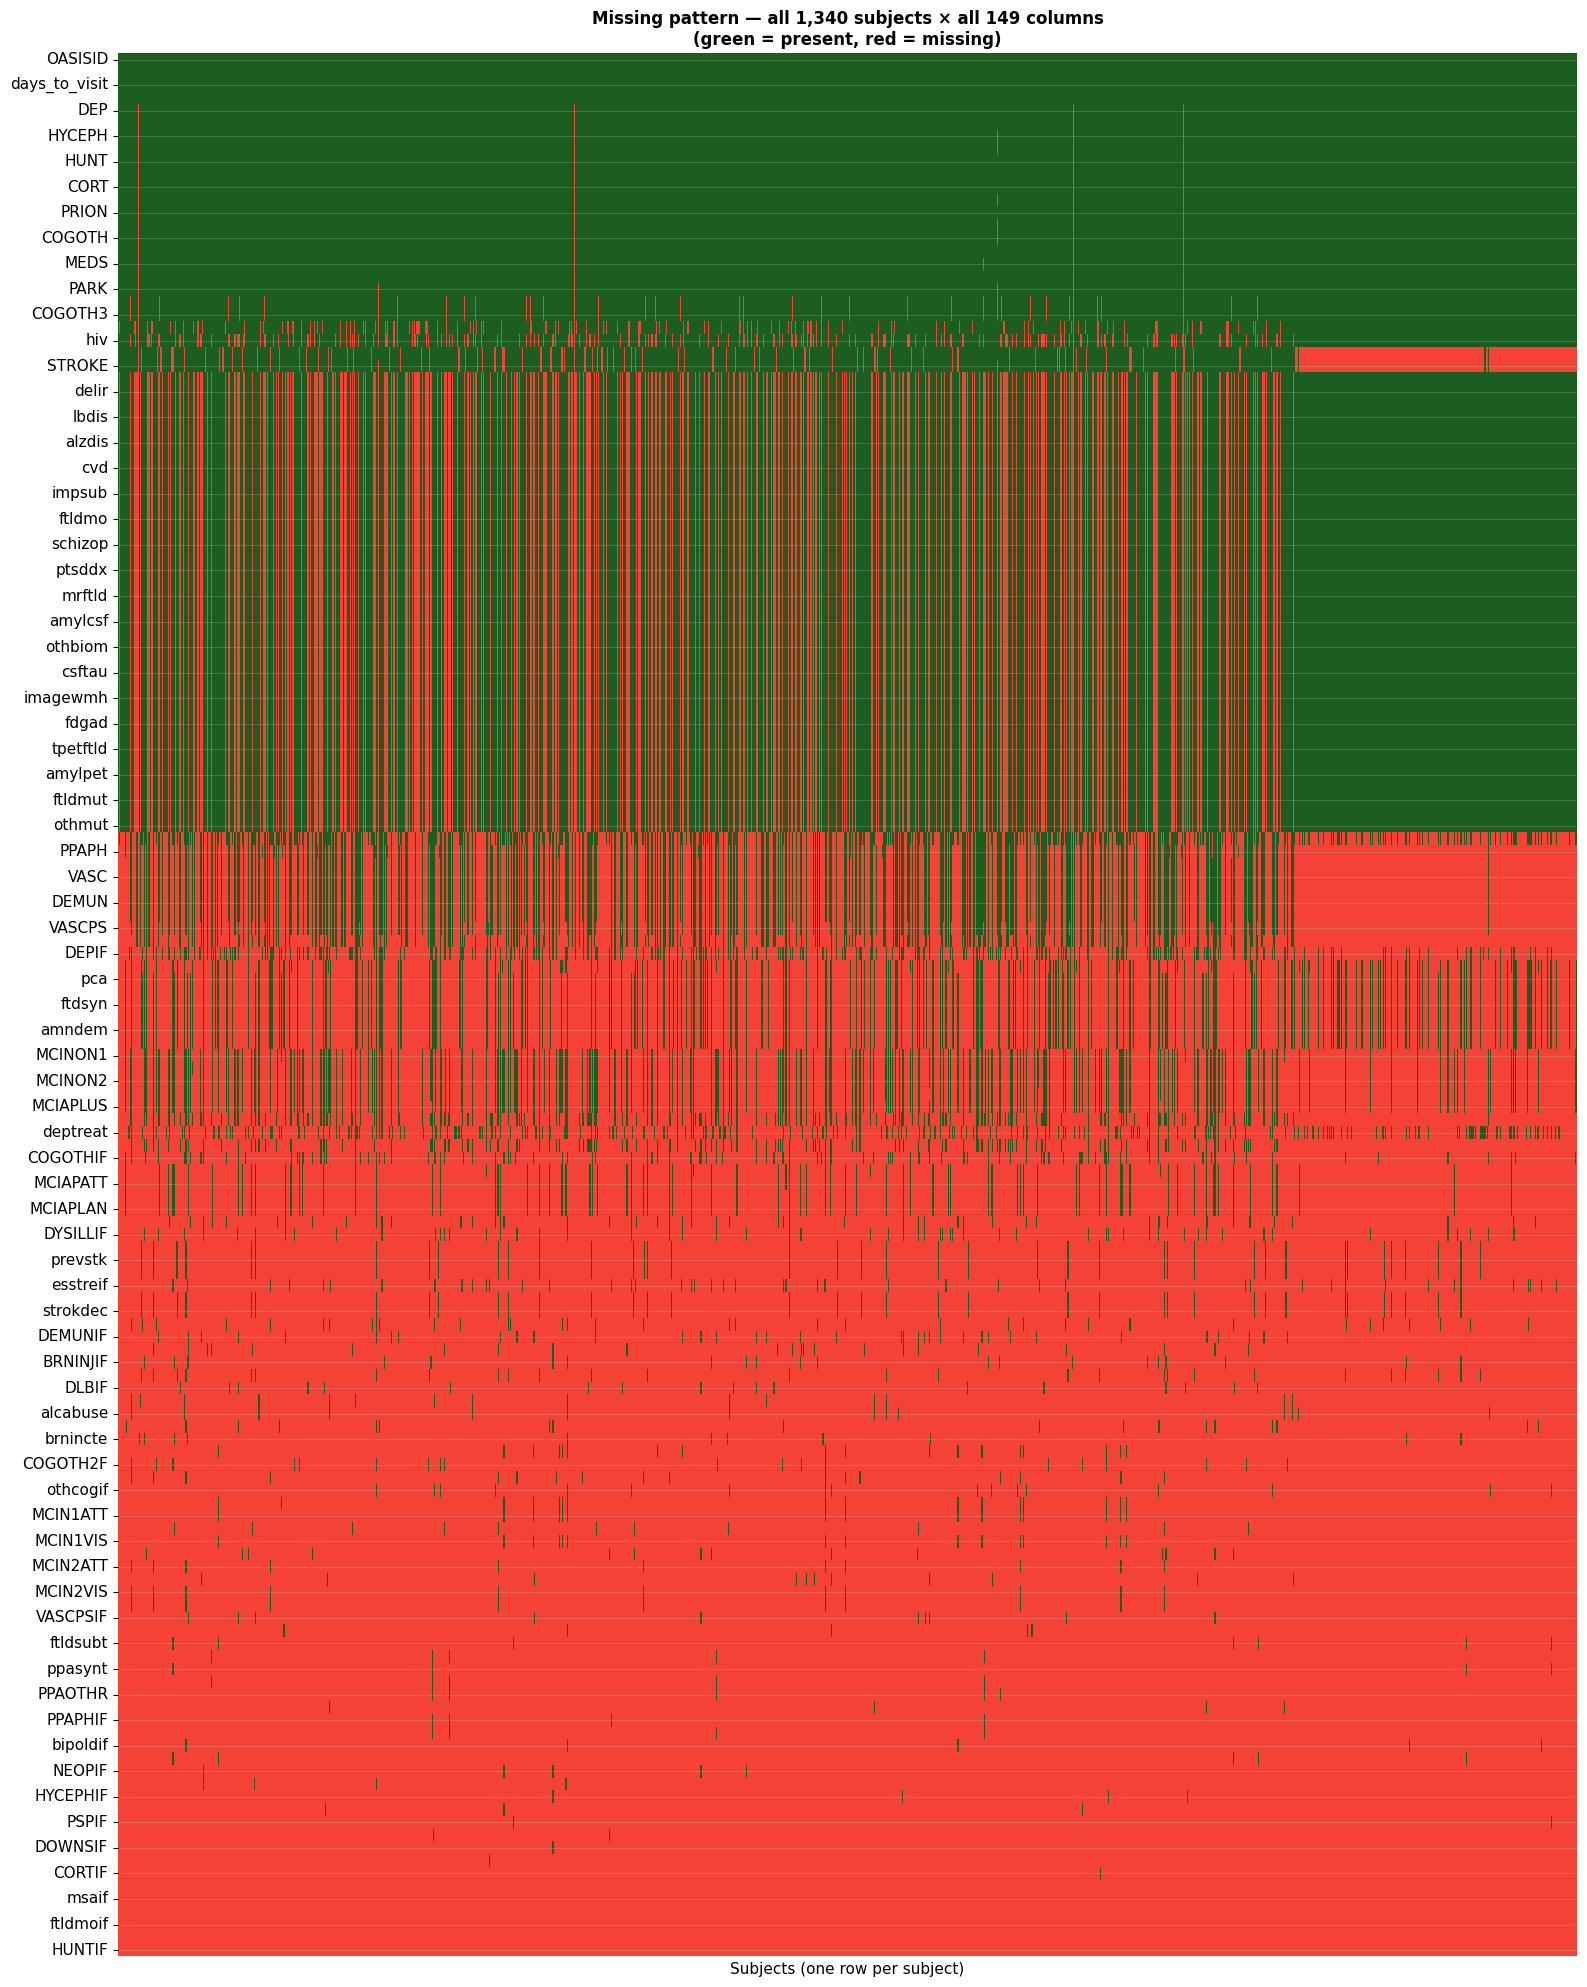

In [4]:
sample = raw.sort_values('days_to_visit').groupby('OASISID').first().reset_index()
show_cols = null_pct.sort_values().index.tolist()
show_cols = [c for c in show_cols if c in sample.columns]

fig, ax = plt.subplots(figsize=(16, 20))
sns.heatmap(sample[show_cols].T.isnull(),
            cbar=False, cmap=['#1B5E20','#F44336'],
            xticklabels=False, ax=ax, linewidths=0)
ax.set_title(
    'Missing pattern — all 1,340 subjects × all 149 columns\n'
    '(green = present, red = missing)',
    fontsize=12, fontweight='bold')
ax.set_xlabel('Subjects (one row per subject)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig_raw_missing_heatmap.png', dpi=DPI, bbox_inches='tight')
plt.show()

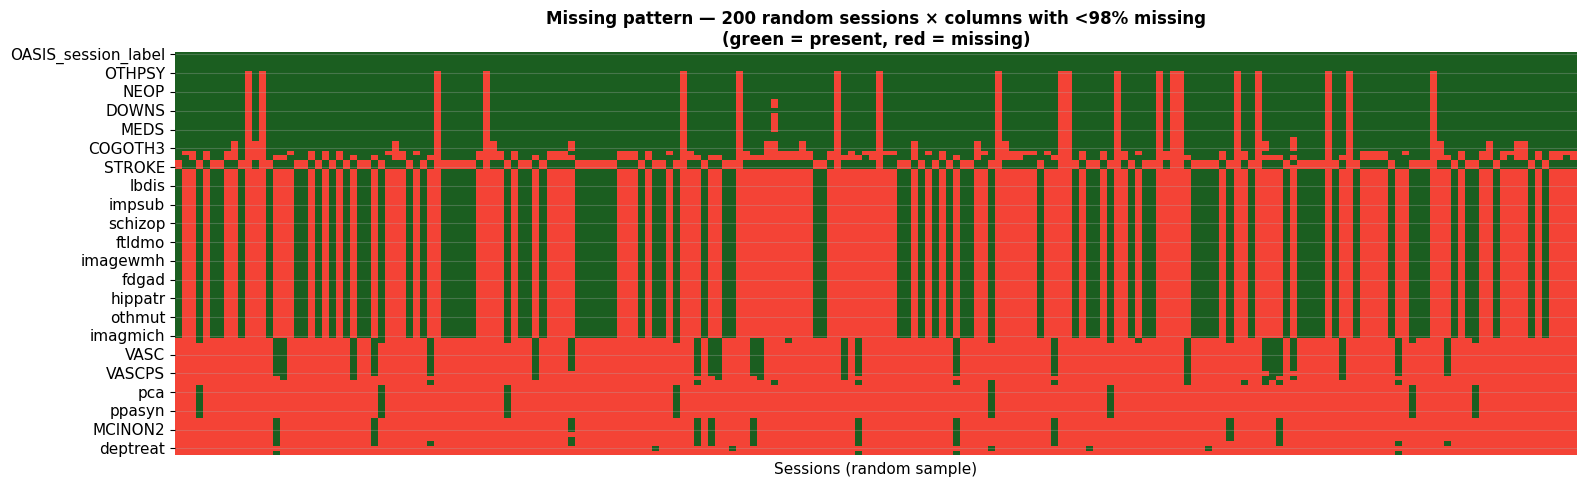

In [5]:
# Select a representative subset of columns to display
show_cols = (null_pct[null_pct < 98]          # drop 100%-empty cols
             .sort_values()
             .index.tolist())

sample = raw[show_cols].sample(n=200, random_state=42)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(sample.T.isnull(),
            cbar=False, cmap=['#1B5E20','#F44336'],
            xticklabels=False, ax=ax, linewidths=0)
ax.set_title(
    'Missing pattern — 200 random sessions × columns with <98% missing\n'
    '(green = present, red = missing)',
    fontsize=12, fontweight='bold')
ax.set_xlabel('Sessions (random sample)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig_raw_missing_heatmap.png', dpi=DPI, bbox_inches='tight')
plt.show()


### 3.2 Missing rate for project-relevant columns

Only a handful of columns are relevant for this project.
Even among them, `DEMENTED` is missing in **77.9%** of rows — because it is only filled
when the clinical assessment explicitly confirms dementia.


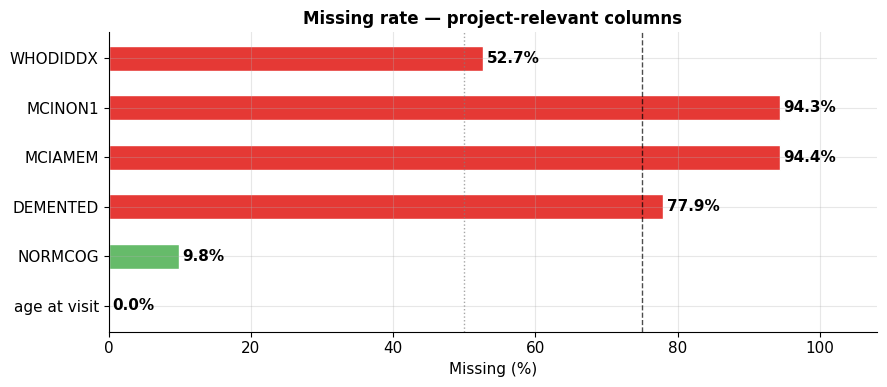

  age at visit       0.0%   Always available — used directly
  NORMCOG            9.8%   CN flag — 9.8% missing
  DEMENTED          77.9%   AD flag — 77.9% missing (only filled when dementia confirmed)
  MCIAMEM           94.4%   MCI (amnestic) — 94.4% missing
  MCINON1           94.3%   MCI (non-amnestic 1) — 94.3% missing
  WHODIDDX          52.7%   Who made the diagnosis — 52.7% missing


In [6]:
key_cols = {
    'age at visit' : 'Always available — used directly',
    'NORMCOG'      : 'CN flag — 9.8% missing',
    'DEMENTED'     : 'AD flag — 77.9% missing (only filled when dementia confirmed)',
    'MCIAMEM'      : 'MCI (amnestic) — 94.4% missing',
    'MCINON1'      : 'MCI (non-amnestic 1) — 94.3% missing',
    'WHODIDDX'     : 'Who made the diagnosis — 52.7% missing',
}

fig, ax = plt.subplots(figsize=(9, 4))
cols   = list(key_cols.keys())
values = [null_pct[c] for c in cols]
colors = ['#1B5E20' if v == 0 else '#66BB6A' if v < 25
          else '#FF8F00' if v < 50 else '#E53935'
          for v in values]

bars = ax.barh(cols, values, color=colors, edgecolor='white', height=0.5)
for bar, v in zip(bars, values):
    ax.text(v + 0.5, bar.get_y()+bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=11, fontweight='bold')
ax.axvline(50, color='grey', lw=1, ls=':', alpha=0.7)
ax.axvline(75, color='black', lw=1, ls='--', alpha=0.7)
ax.set_xlim(0, 108)
ax.set_title('Missing rate — project-relevant columns', fontsize=12, fontweight='bold')
ax.set_xlabel('Missing (%)')

plt.tight_layout()
plt.savefig('fig_raw_missing_keycols.png', dpi=DPI, bbox_inches='tight')
plt.show()

for col, desc in key_cols.items():
    print(f'  {col:15s}  {null_pct[col]:5.1f}%   {desc}')


## 4. Longitudinal structure — sessions per subject

OASIS-3 is a **longitudinal** dataset: each subject was visited multiple times over years.
Every row is a session, not a subject. For the DL classification task in this project,
we need **one observation per subject** — the first session with valid imaging data.


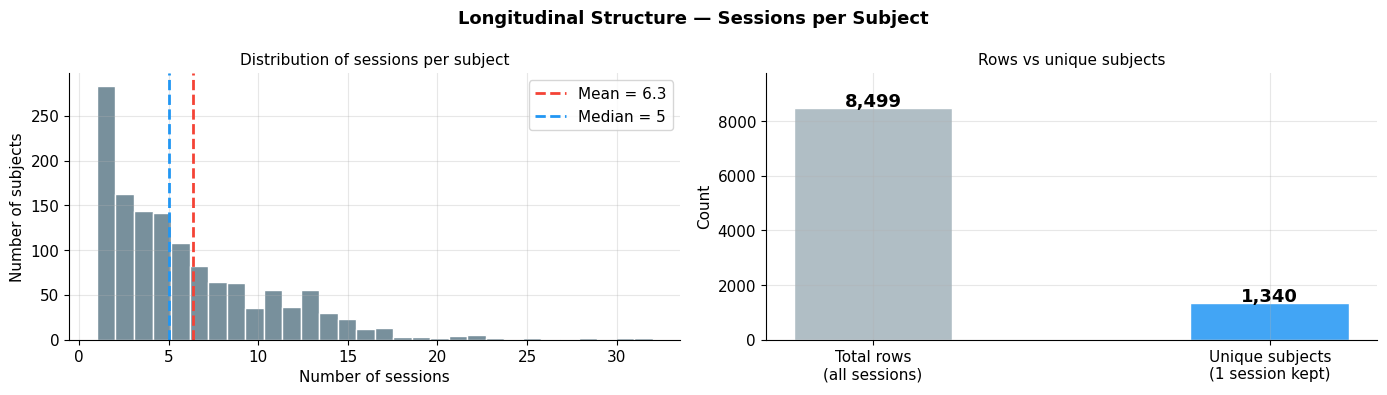

Sessions per subject:  mean=6.3,  median=5,  max=32
Subjects with >1 session: 1223 (91.3%)

→ 8,499 rows collapsed to 1,340 unique subjects.
  Only the first session with T1w + T2w + BOLD was retained per subject.


In [7]:
sps = raw.groupby('OASISID').size().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Longitudinal Structure — Sessions per Subject', fontsize=13, fontweight='bold')

# Histogram
ax = axes[0]
ax.hist(sps.values, bins=30, color='#78909C', edgecolor='white')
ax.axvline(sps.mean(),   color='#F44336', lw=2, ls='--', label=f'Mean = {sps.mean():.1f}')
ax.axvline(sps.median(), color='#2196F3', lw=2, ls='--', label=f'Median = {sps.median():.0f}')
ax.set_title('Distribution of sessions per subject', fontsize=11)
ax.set_xlabel('Number of sessions'); ax.set_ylabel('Number of subjects')
ax.legend()

# Bar: total rows vs unique subjects
ax = axes[1]
vals   = [len(raw), raw['OASISID'].nunique()]
labels = ['Total rows\n(all sessions)', 'Unique subjects\n(1 session kept)']
bars   = ax.bar(labels, vals, color=['#B0BEC5','#42A5F5'],
                edgecolor='white', width=0.4)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f'{v:,}', ha='center', fontsize=13, fontweight='bold')
ax.set_title('Rows vs unique subjects', fontsize=11)
ax.set_ylabel('Count'); ax.set_ylim(0, max(vals)*1.15)

plt.tight_layout()
plt.savefig('fig_raw_longitudinal.png', dpi=DPI, bbox_inches='tight')
plt.show()

print(f'Sessions per subject:  mean={sps.mean():.1f},  median={sps.median():.0f},  max={sps.max()}')
print(f'Subjects with >1 session: {(sps>1).sum()} ({100*(sps>1).mean():.1f}%)')
print(f'\n→ 8,499 rows collapsed to 1,340 unique subjects.')
print(f'  Only the first session with T1w + T2w + BOLD was retained per subject.')


## 5. Correlation matrix — usable columns

Only **23 columns** have <50% missing data. Among them, only the numeric ones
are used to compute the correlation matrix. This confirms how little usable
structured information the raw dataset contains beyond age and basic diagnosis flags.


Columns with <50% missing: 23  (out of 149)
Of which numeric         : 21
Numeric cols: ['hiv', 'ALCDEM', 'COGOTH3', 'COGOTH2', 'PARK', 'NORMCOG', 'MEDS', 'DYSILL', 'HYCEPH', 'HUNT', 'BRNINJ', 'DOWNS', 'CORT', 'NEOP', 'PSP', 'COGOTH', 'PRION', 'OTHPSY', 'DEP', 'days_to_visit', 'age at visit']


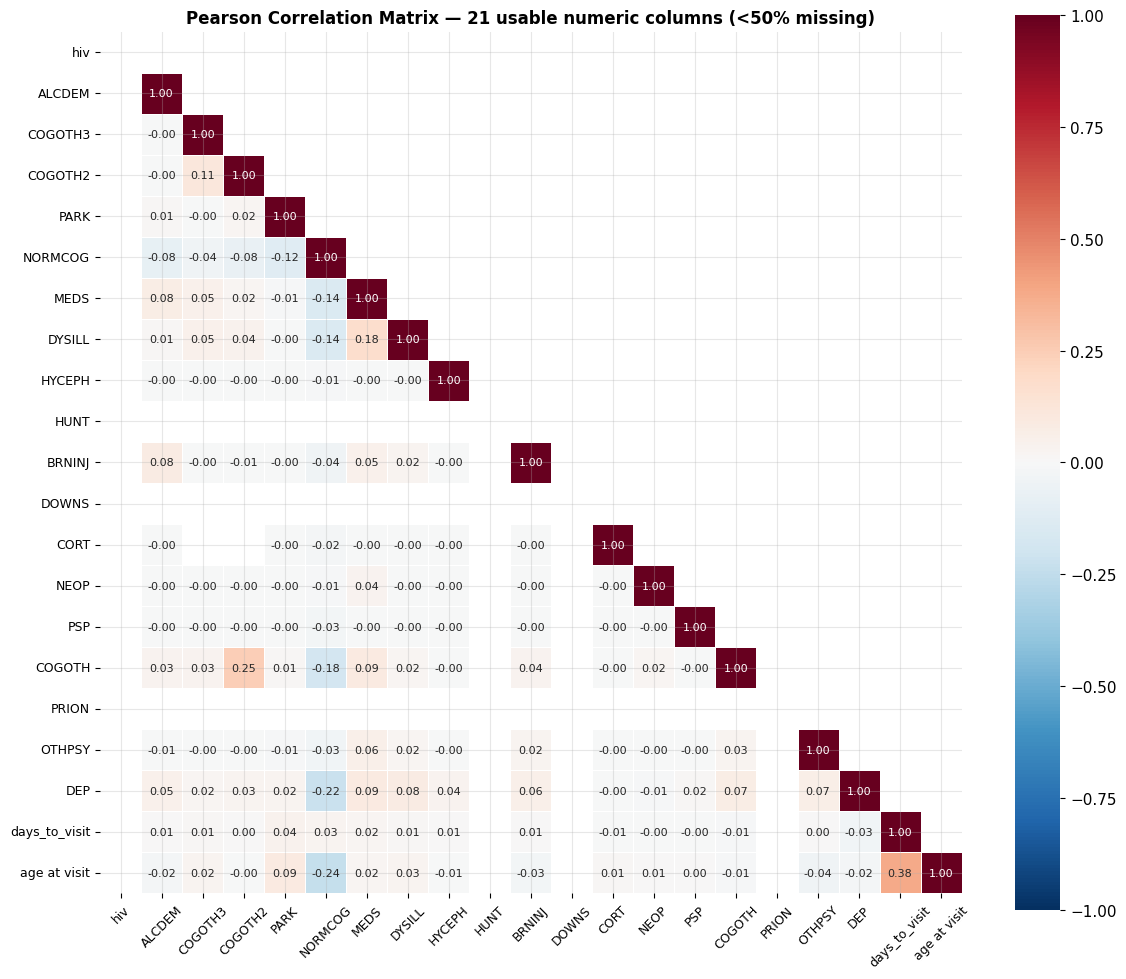


→ Most usable columns are rare condition flags (PARK, DEP, BRNINJ…)
  They have near-zero variance and near-zero correlation with each other.
  Only age at visit and NORMCOG carry consistent signal across all subjects.


In [8]:
# Only columns with <50% missing and numeric
usable = null_pct[null_pct < 50].index.tolist()
num_cols = raw[usable].select_dtypes(include=[np.number]).columns.tolist()

print(f'Columns with <50% missing: {len(usable)}  (out of 149)')
print(f'Of which numeric         : {len(num_cols)}')
print(f'Numeric cols: {num_cols}')

corr = raw[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, mask=mask,
            linewidths=0.5, linecolor='white', square=True, ax=ax,
            annot_kws={'size': 8})
ax.set_title(
    f'Pearson Correlation Matrix — {len(num_cols)} usable numeric columns (<50% missing)',
    fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig('fig_raw_correlation.png', dpi=DPI, bbox_inches='tight')
plt.show()

print('\n→ Most usable columns are rare condition flags (PARK, DEP, BRNINJ…)')
print('  They have near-zero variance and near-zero correlation with each other.')
print('  Only age at visit and NORMCOG carry consistent signal across all subjects.')


## 6. Summary — why most of the raw data is discarded

| Issue | Detail | Decision |
|---|---|---|
| **100% missing columns** | 6 columns completely empty | Dropped |
| **>75% missing columns** | 88 out of 149 columns | Dropped — no usable signal |
| **Longitudinal redundancy** | Mean 6.3 sessions/subject (max 32) | Only first valid session retained |
| **DEMENTED 77.9% missing** | Only filled when dementia confirmed | Used with NORMCOG to assign CN/AD label |
| **MCI underrepresentation** | 55 subjects (4.8% of labelled cohort) | Excluded — insufficient for DL training |
| **Usable columns** | Only 23 out of 149 have <50% missing | Final cohort retains 7 essential variables |

After all filtering steps: **1,086 subjects, 0 missing values, 7 variables** → `OASIS3_metadata_final.csv`  
The final cohort EDA is covered in a separate notebook.
